# Sephora Products & Skincare — Exploratory Data Analysis
**Dataset:** Sephora Products and Skincare Reviews (Kaggle)  
**Oleh:** Muhammad Rifai | [GitHub](https://github.com/ahmadripai047)

---
##  Deskripsi Dataset
Dataset ini berisi **8.494 produk** dari platform Sephora yang mencakup informasi produk kecantikan mulai dari skincare, makeup, fragrance, hingga hair care. Data mencakup harga, rating, jumlah ulasan, merek, kategori produk, serta berbagai atribut seperti apakah produk vegan, cruelty-free, eksklusif Sephora, dll.

| Kolom | Keterangan |
|---|---|
| `product_name` | Nama produk |
| `brand_name` | Nama brand |
| `loves_count` | Jumlah pengguna yang "love" produk |
| `rating` | Rating rata-rata (1–5) |
| `reviews` | Jumlah ulasan |
| `price_usd` | Harga dalam USD |
| `primary_category` | Kategori utama (Skincare, Makeup, dll) |
| `highlights` | Fitur produk (Vegan, Cruelty-Free, dll) |
| `sephora_exclusive` | Eksklusif di Sephora (0/1) |


## 1. Import Library & Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import ast
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Style
sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 130

# Load
df = pd.read_csv('product_info.csv')
print(f"Dataset loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")
df.head(3)

Dataset loaded: 8,494 rows × 27 columns


,product_id,product_name,brand_id,brand_name,loves_count,rating,reviews,size,variation_type,variation_value,...,online_only,out_of_stock,sephora_exclusive,highlights,primary_category,secondary_category,tertiary_category,child_count,child_max_price,child_min_price
0,P473671,Fragrance Discovery Set,6342,19-69,6320,3.6364,11.0,NaN,NaN,NaN,...,1,0,0,"['Unisex/ Genderless Scent', 'Warm &Spicy Scen...",Fragrance,Value & Gift Sets,Perfume Gift Sets,0,NaN,NaN
1,P473668,La Habana Eau de Parfum,6342,19-69,3827,4.1538,13.0,3.4 oz/ 100 mL,Size + Concentration + Formulation,3.4 oz/ 100 mL,...,1,0,0,"['Unisex/ Genderless Scent', 'Layerable Scent'...",Fragrance,Women,Perfume,2,85.0,30.0
2,P473662,Rainbow Bar Eau de Parfum,6342,19-69,3253,4.2500,16.0,3.4 oz/ 100 mL,Size + Concentration + Formulation,3.4 oz/ 100 mL,...,1,0,0,"['Unisex/ Genderless Scent', 'Layerable Scent'...",Fragrance,Women,Perfume,2,75.0,30.0


## 2. Data Overview & Cleaning

In [2]:
# Shape & dtypes
print("Shape:", df.shape)
print("\n Dtypes:")
print(df.dtypes)

Shape: (8494, 27)

 Dtypes:
product_id             object
product_name           object
brand_id                int64
brand_name             object
loves_count             int64
rating                float64
reviews               float64
size                   object
variation_type         object
variation_value        object
variation_desc         object
ingredients            object
price_usd             float64
value_price_usd       float64
sale_price_usd        float64
limited_edition         int64
new                     int64
online_only             int64
out_of_stock            int64
sephora_exclusive       int64
highlights             object
primary_category       object
secondary_category     object
tertiary_category      object
child_count             int64
child_max_price       float64
child_min_price       float64
dtype: object


In [3]:
# Missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)
missing_df = pd.DataFrame({'Missing': missing, 'Pct (%)': missing_pct})
missing_df[missing_df['Missing'] > 0].sort_values('Missing', ascending=False)

,Missing,Pct (%)
sale_price_usd,8224,96.8
value_price_usd,8043,94.7
variation_desc,7244,85.3
child_max_price,5740,67.6
child_min_price,5740,67.6
highlights,2207,26.0
size,1631,19.2
variation_value,1598,18.8
variation_type,1444,17.0
tertiary_category,990,11.7


In [4]:
# ── Cleaning & Feature Engineering ──

# Parse list columns
def parse_list(x):
    try: return ast.literal_eval(x)
    except: return []

df['highlights_list'] = df['highlights'].apply(parse_list)

# Price segments
bins   = [0, 25, 50, 100, 200, 2000]
labels = ['Budget (<$25)', 'Mid ($25–50)', 'Premium ($50–100)', 'Luxury ($100–200)', 'Ultra-Luxury ($200+)']
df['price_segment'] = pd.cut(df['price_usd'], bins=bins, labels=labels)

# Rating bucket
df['rating_bucket'] = pd.cut(df['rating'], bins=[0,2,3,4,4.5,5],
                              labels=['Poor','Fair','Good','Great','Excellent'])

# Log loves (for viz)
df['log_loves'] = np.log1p(df['loves_count'])

print("Feature engineering complete")
df[['price_segment','rating_bucket','log_loves']].describe()

Feature engineering complete


,log_loves
count,8494.000000
mean,9.107932
std,1.791368
min,0.000000
25%,8.231908
50%,9.198369
75%,10.197732
max,14.152746


In [5]:
# Basic stats
df[['price_usd','rating','reviews','loves_count']].describe().round(2)

,price_usd,rating,reviews,loves_count
count,8494.00,8216.00,8216.00,8494.00
mean,51.66,4.19,448.55,29179.57
std,53.67,0.52,1101.98,66092.12
min,3.00,1.00,1.00,0.00
25%,25.00,3.98,26.00,3758.00
50%,35.00,4.29,122.00,9880.00
75%,58.00,4.53,418.00,26841.25
max,1900.00,5.00,21281.00,1401068.00


## 3. Analisis Kategori Produk

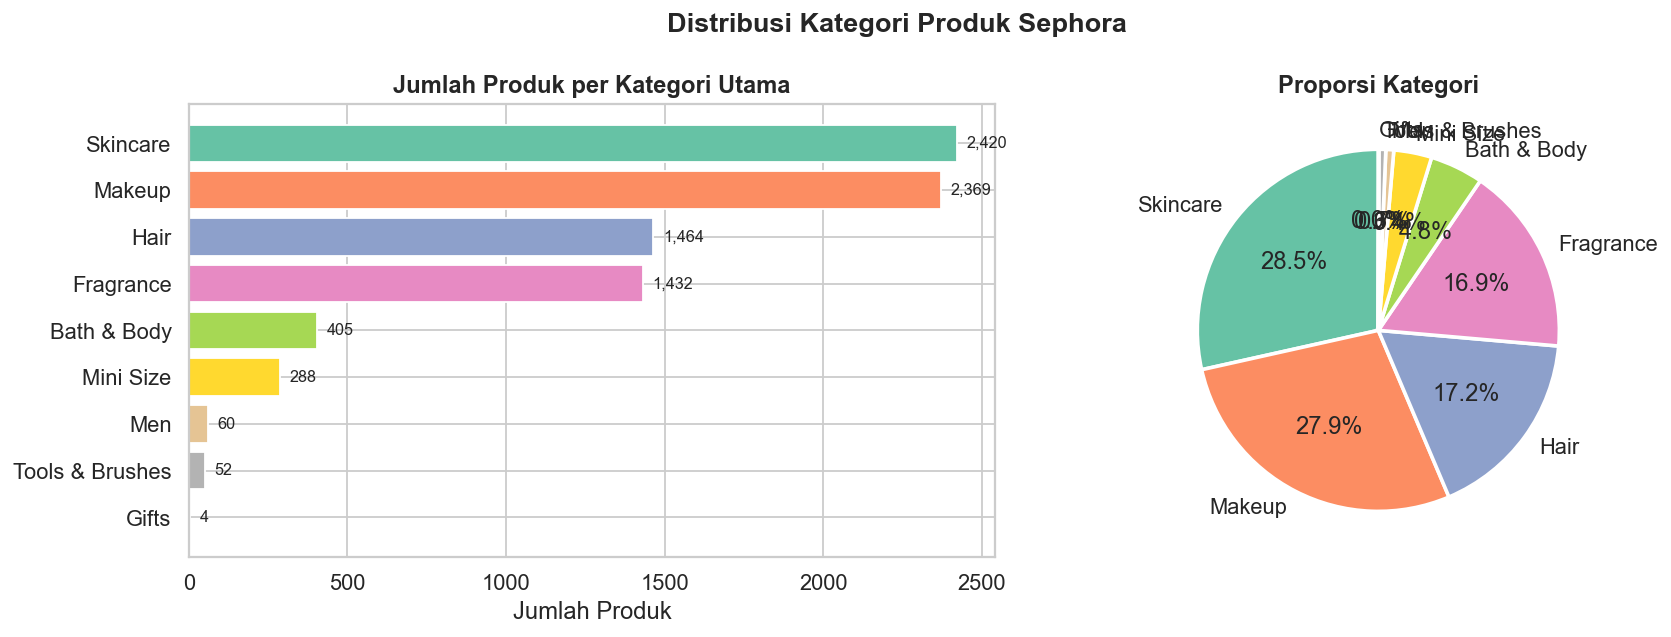

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Distribusi Kategori Produk Sephora', fontsize=15, fontweight='bold')

# Primary category
cat_counts = df['primary_category'].value_counts()
colors = sns.color_palette('Set2', len(cat_counts))
axes[0].barh(cat_counts.index[::-1], cat_counts.values[::-1], color=colors[::-1])
for i, v in enumerate(cat_counts.values[::-1]):
    axes[0].text(v + 30, i, f'{v:,}', va='center', fontsize=9)
axes[0].set_title('Jumlah Produk per Kategori Utama', fontweight='bold')
axes[0].set_xlabel('Jumlah Produk')

# Pie chart
axes[1].pie(cat_counts.values, labels=cat_counts.index, autopct='%1.1f%%',
            colors=colors, startangle=90,
            wedgeprops=dict(edgecolor='white', linewidth=2))
axes[1].set_title('Proporsi Kategori', fontweight='bold')

plt.tight_layout()
plt.show()

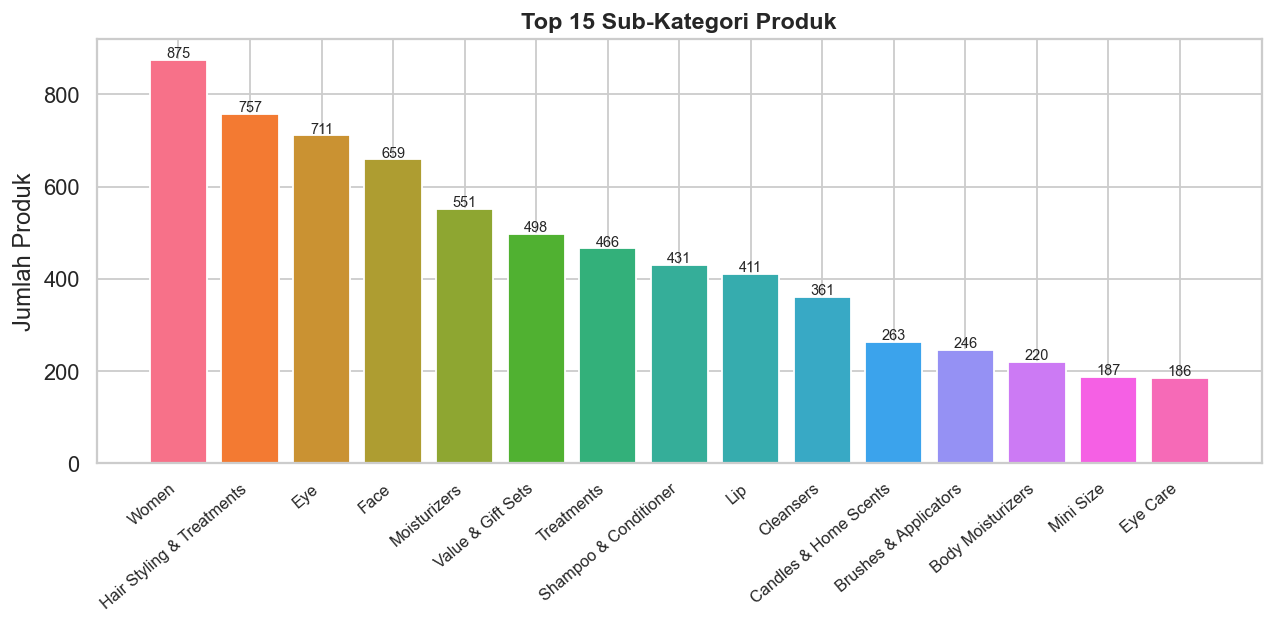

In [7]:
# Secondary category top 15
sec_counts = df['secondary_category'].value_counts().head(15)
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(range(len(sec_counts)), sec_counts.values,
              color=sns.color_palette('husl', len(sec_counts)))
ax.set_xticks(range(len(sec_counts)))
ax.set_xticklabels(sec_counts.index, rotation=40, ha='right', fontsize=9)
ax.set_title('Top 15 Sub-Kategori Produk', fontsize=13, fontweight='bold')
ax.set_ylabel('Jumlah Produk')
for bar in bars:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+5,
            str(bar.get_height()), ha='center', fontsize=8)
plt.tight_layout()
plt.show()

## 4. Analisis Brand

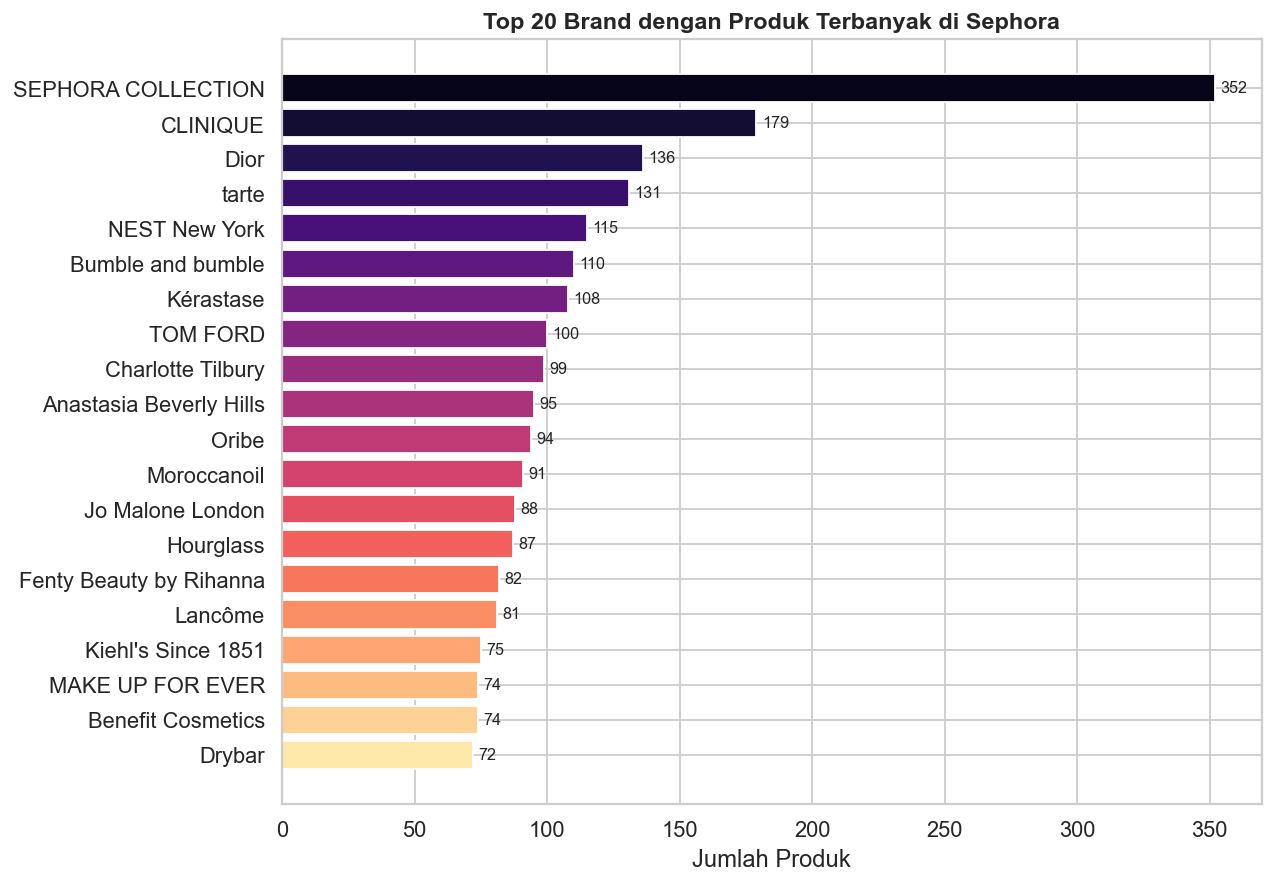

In [8]:
top_brands = df['brand_name'].value_counts().head(20)
fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(top_brands.index[::-1], top_brands.values[::-1],
               color=sns.color_palette('magma', 20)[::-1])
for bar in bars:
    ax.text(bar.get_width()+2, bar.get_y()+bar.get_height()/2,
            str(int(bar.get_width())), va='center', fontsize=9)
ax.set_title('Top 20 Brand dengan Produk Terbanyak di Sephora', fontsize=13, fontweight='bold')
ax.set_xlabel('Jumlah Produk')
plt.tight_layout()
plt.show()

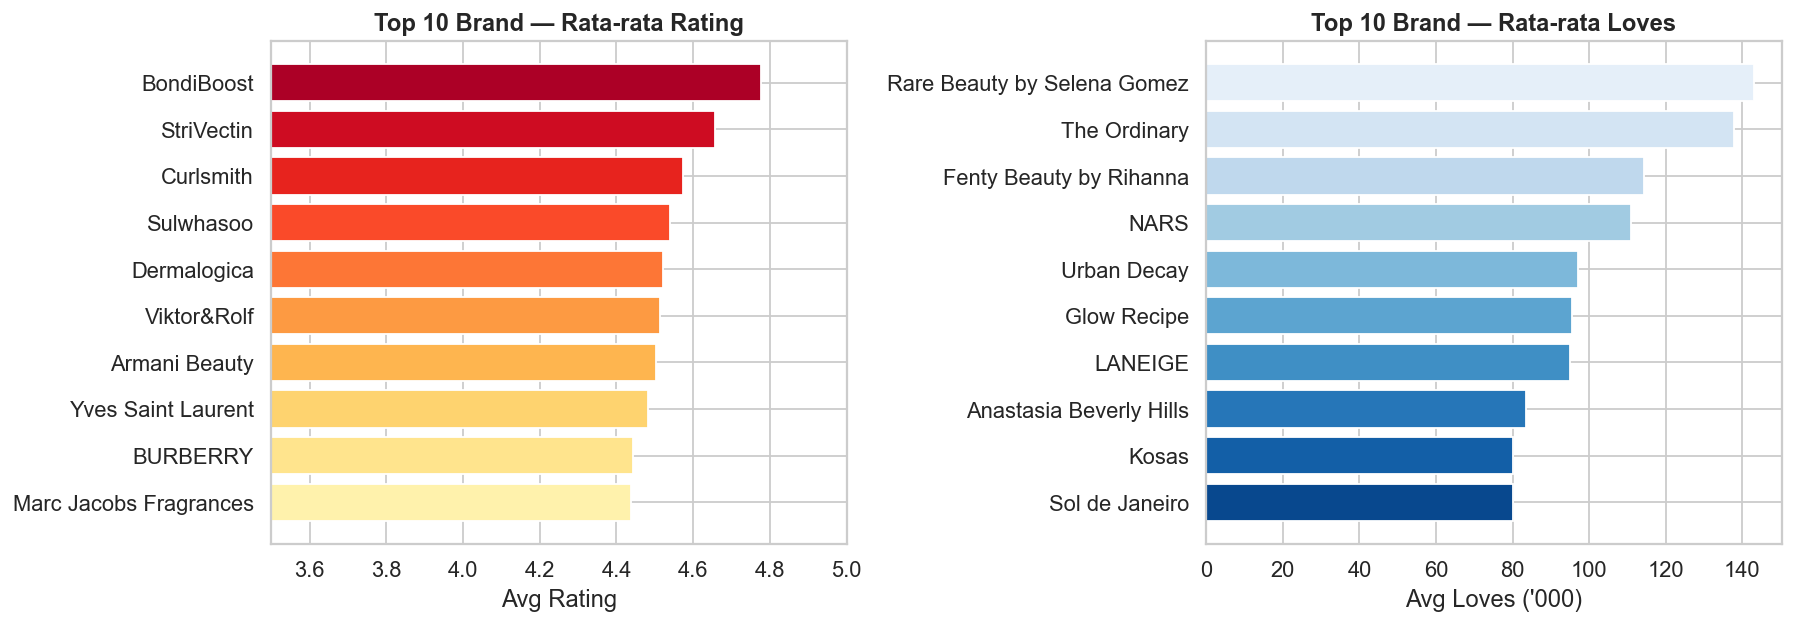

In [9]:
# Brand by avg rating (min 20 produk)
brand_stats = df.groupby('brand_name').agg(
    avg_rating=('rating','mean'),
    total_products=('product_id','count'),
    avg_loves=('loves_count','mean'),
    avg_price=('price_usd','mean')
).reset_index()
brand_stats = brand_stats[brand_stats['total_products'] >= 20].sort_values('avg_rating', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# Top rated brands
top10 = brand_stats.head(10)
axes[0].barh(top10['brand_name'][::-1], top10['avg_rating'][::-1],
             color=sns.color_palette('YlOrRd', 10))
axes[0].set_xlim(3.5, 5)
axes[0].set_title('Top 10 Brand — Rata-rata Rating', fontweight='bold')
axes[0].set_xlabel('Avg Rating')

# Most loved brands
top_loved = brand_stats.nlargest(10, 'avg_loves')
axes[1].barh(top_loved['brand_name'][::-1], top_loved['avg_loves'][::-1]/1000,
             color=sns.color_palette('Blues_r', 10))
axes[1].set_title('Top 10 Brand — Rata-rata Loves', fontweight='bold')
axes[1].set_xlabel("Avg Loves ('000)")

plt.tight_layout()
plt.show()

## 5. Analisis Harga

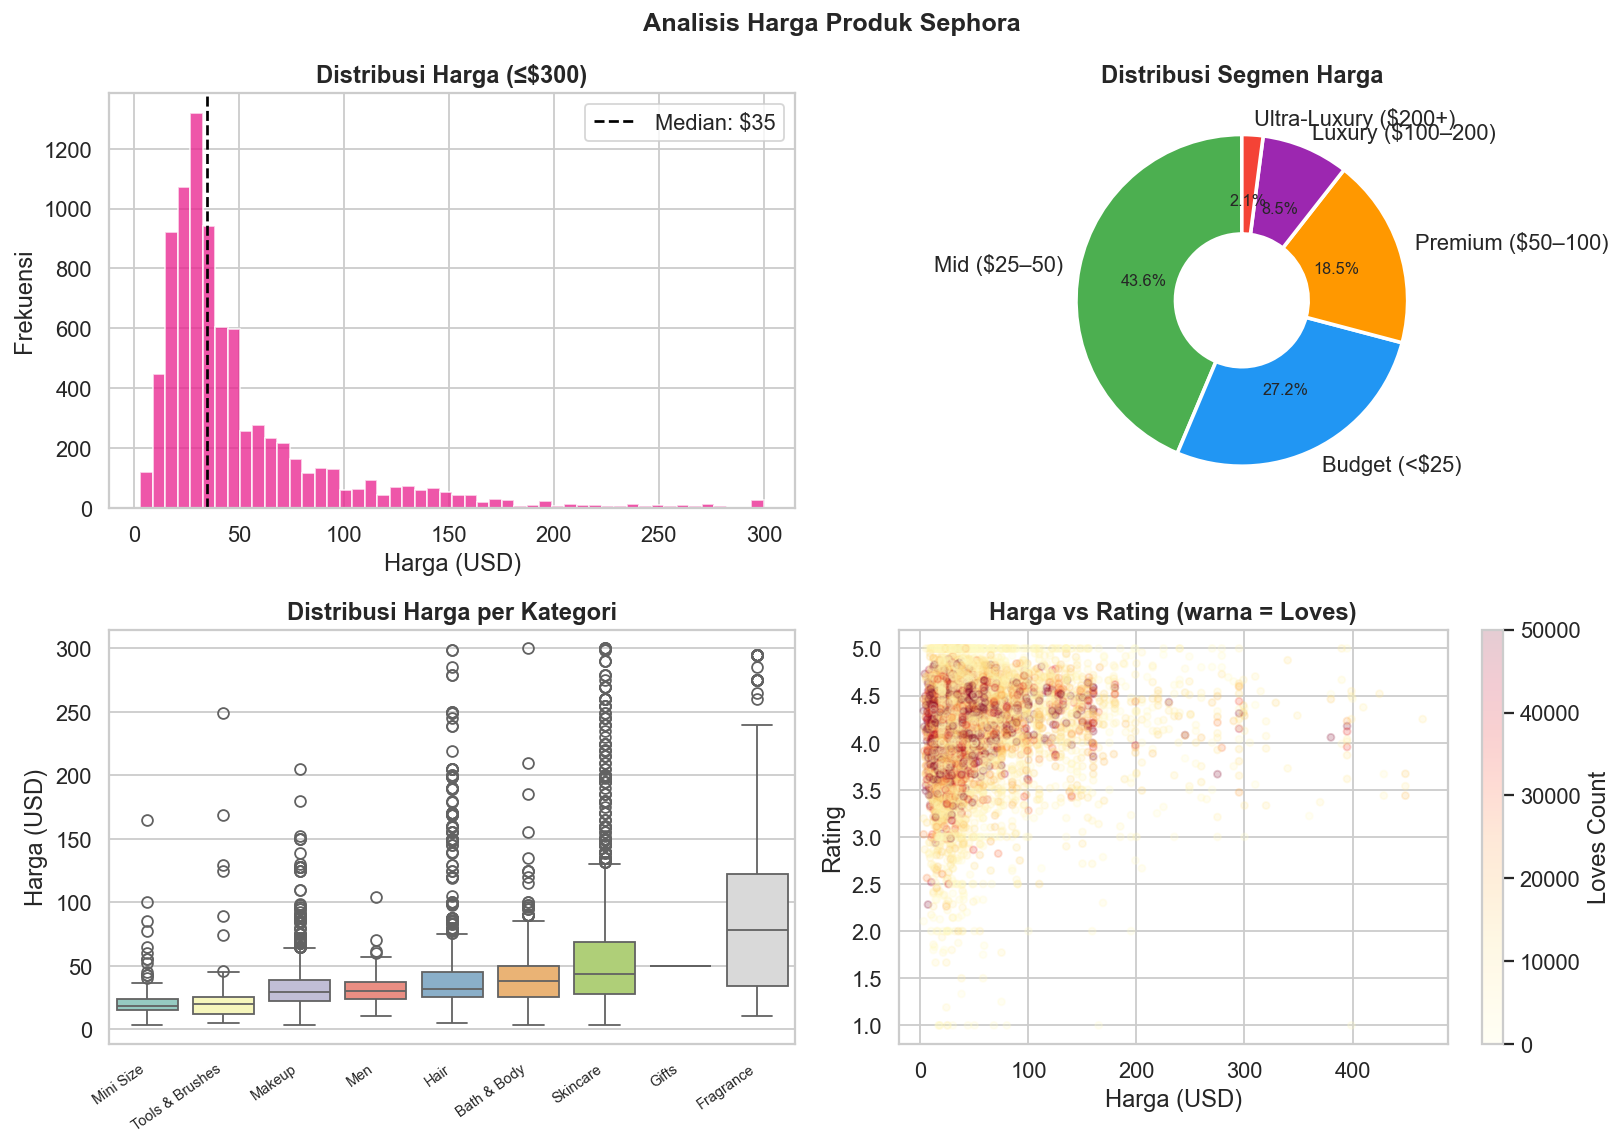

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle('Analisis Harga Produk Sephora', fontsize=14, fontweight='bold')

# Price distribution (trimmed)
trimmed = df[df['price_usd'] <= 300]
axes[0,0].hist(trimmed['price_usd'], bins=50, color='#E91E8C', alpha=0.75, edgecolor='white')
axes[0,0].axvline(df['price_usd'].median(), color='black', linestyle='--', linewidth=1.5,
                   label=f"Median: ${df['price_usd'].median():.0f}")
axes[0,0].set_title('Distribusi Harga (≤$300)', fontweight='bold')
axes[0,0].set_xlabel('Harga (USD)'); axes[0,0].set_ylabel('Frekuensi')
axes[0,0].legend()

# Price segment donut
seg_counts = df['price_segment'].value_counts()
colors_seg = ['#4CAF50','#2196F3','#FF9800','#9C27B0','#F44336']
wedges, texts, auts = axes[0,1].pie(seg_counts.values, labels=seg_counts.index,
    autopct='%1.1f%%', colors=colors_seg,
    wedgeprops=dict(width=0.6, edgecolor='white', linewidth=2), startangle=90)
for a in auts: a.set_fontsize(9)
axes[0,1].set_title('Distribusi Segmen Harga', fontweight='bold')

# Price by category boxplot
cat_order = df.groupby('primary_category')['price_usd'].median().sort_values().index
df_trim = df[df['price_usd'] <= 300]
sns.boxplot(data=df_trim, x='primary_category', y='price_usd',
            order=cat_order, palette='Set3', ax=axes[1,0])
axes[1,0].set_xticklabels(axes[1,0].get_xticklabels(), rotation=35, ha='right', fontsize=8)
axes[1,0].set_title('Distribusi Harga per Kategori', fontweight='bold')
axes[1,0].set_xlabel(''); axes[1,0].set_ylabel('Harga (USD)')

# Price vs Rating scatter
sample = df[df['price_usd'] <= 500].dropna(subset=['rating'])
sc = axes[1,1].scatter(sample['price_usd'], sample['rating'],
                        alpha=0.2, s=15, c=sample['loves_count'],
                        cmap='YlOrRd', norm=plt.Normalize(0, 50000))
plt.colorbar(sc, ax=axes[1,1], label='Loves Count')
axes[1,1].set_xlabel('Harga (USD)'); axes[1,1].set_ylabel('Rating')
axes[1,1].set_title('Harga vs Rating (warna = Loves)', fontweight='bold')

plt.tight_layout()
plt.show()

## 6. Analisis Rating & Popularitas

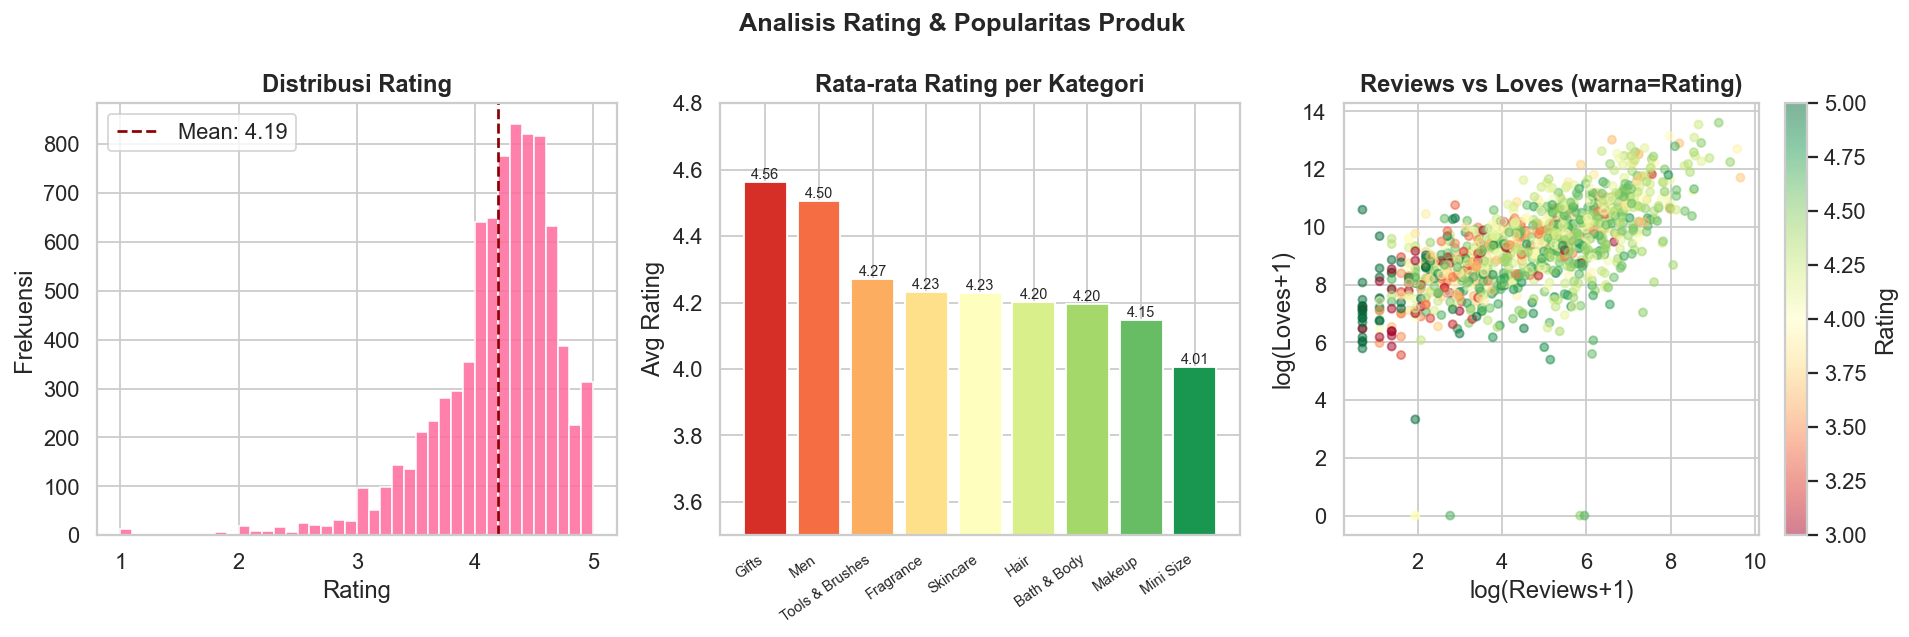

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Analisis Rating & Popularitas Produk', fontsize=14, fontweight='bold')

# Rating distribution
df_rated = df.dropna(subset=['rating'])
axes[0].hist(df_rated['rating'], bins=40, color='#FF6B9D', edgecolor='white', alpha=0.85)
axes[0].axvline(df_rated['rating'].mean(), color='darkred', linestyle='--',
                label=f"Mean: {df_rated['rating'].mean():.2f}")
axes[0].set_title('Distribusi Rating', fontweight='bold')
axes[0].set_xlabel('Rating'); axes[0].set_ylabel('Frekuensi')
axes[0].legend()

# Rating by category
cat_rating = df_rated.groupby('primary_category')['rating'].mean().sort_values(ascending=False)
bars = axes[1].bar(range(len(cat_rating)), cat_rating.values,
                   color=sns.color_palette('RdYlGn', len(cat_rating)))
axes[1].set_xticks(range(len(cat_rating)))
axes[1].set_xticklabels(cat_rating.index, rotation=35, ha='right', fontsize=8)
axes[1].set_ylim(3.5, 4.8)
axes[1].set_title('Rata-rata Rating per Kategori', fontweight='bold')
axes[1].set_ylabel('Avg Rating')
for bar in bars:
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                 f'{bar.get_height():.2f}', ha='center', fontsize=8)

# Loves vs reviews
sample = df.dropna(subset=['rating']).sample(min(1000, len(df)))
sc2 = axes[2].scatter(np.log1p(sample['reviews']), np.log1p(sample['loves_count']),
                       c=sample['rating'], cmap='RdYlGn', alpha=0.5, s=20,
                       vmin=3, vmax=5)
plt.colorbar(sc2, ax=axes[2], label='Rating')
axes[2].set_xlabel('log(Reviews+1)'); axes[2].set_ylabel('log(Loves+1)')
axes[2].set_title('Reviews vs Loves (warna=Rating)', fontweight='bold')

plt.tight_layout()
plt.show()

## 7. Analisis Fitur & Highlights Produk

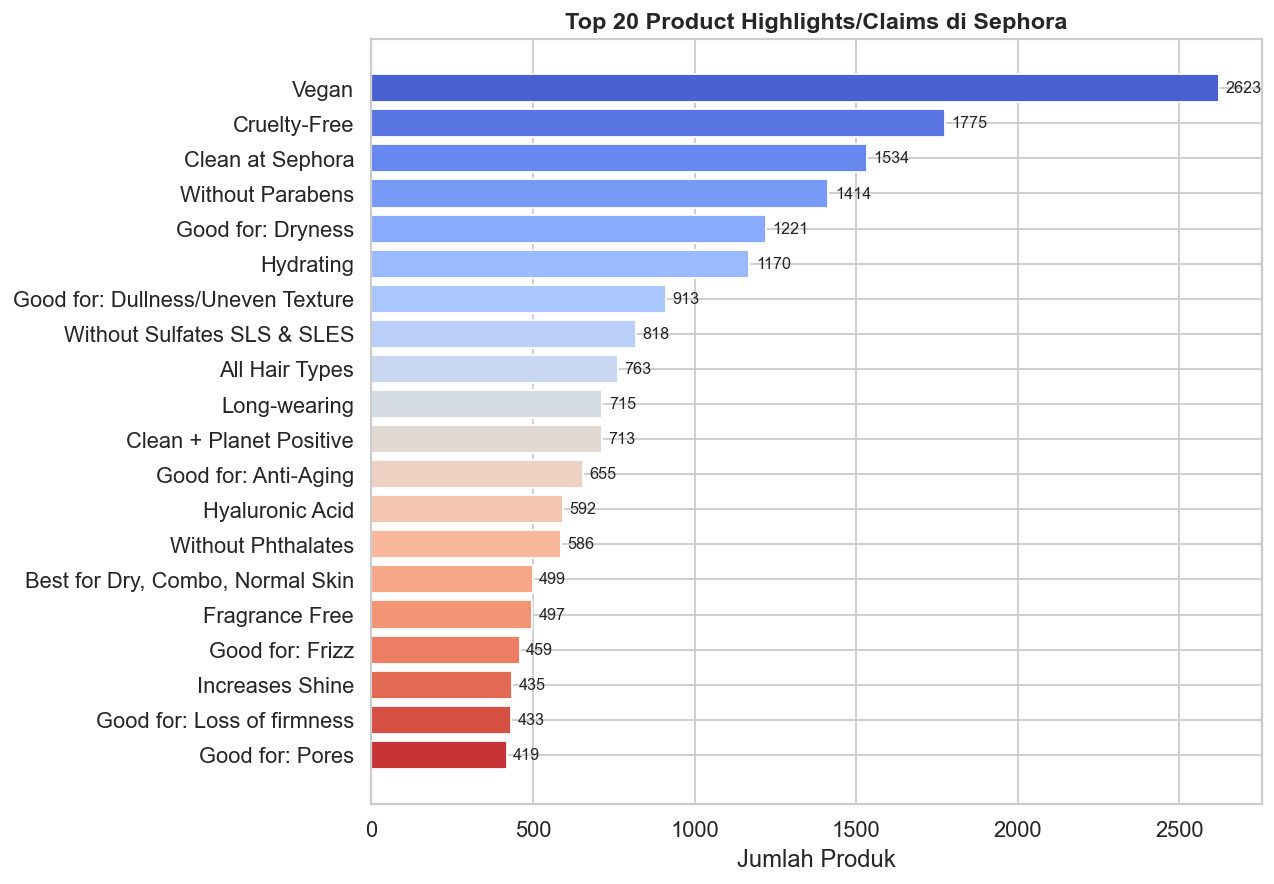

In [12]:
# Top highlights
all_hl = [h for sub in df['highlights_list'] for h in sub]
hl_counts = Counter(all_hl).most_common(20)
hl_df = pd.DataFrame(hl_counts, columns=['Highlight','Count'])

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(hl_df['Highlight'][::-1], hl_df['Count'][::-1],
               color=sns.color_palette('coolwarm_r', 20))
for bar in bars:
    ax.text(bar.get_width()+20, bar.get_y()+bar.get_height()/2,
            str(int(bar.get_width())), va='center', fontsize=9)
ax.set_title('Top 20 Product Highlights/Claims di Sephora', fontsize=13, fontweight='bold')
ax.set_xlabel('Jumlah Produk')
plt.tight_layout()
plt.show()

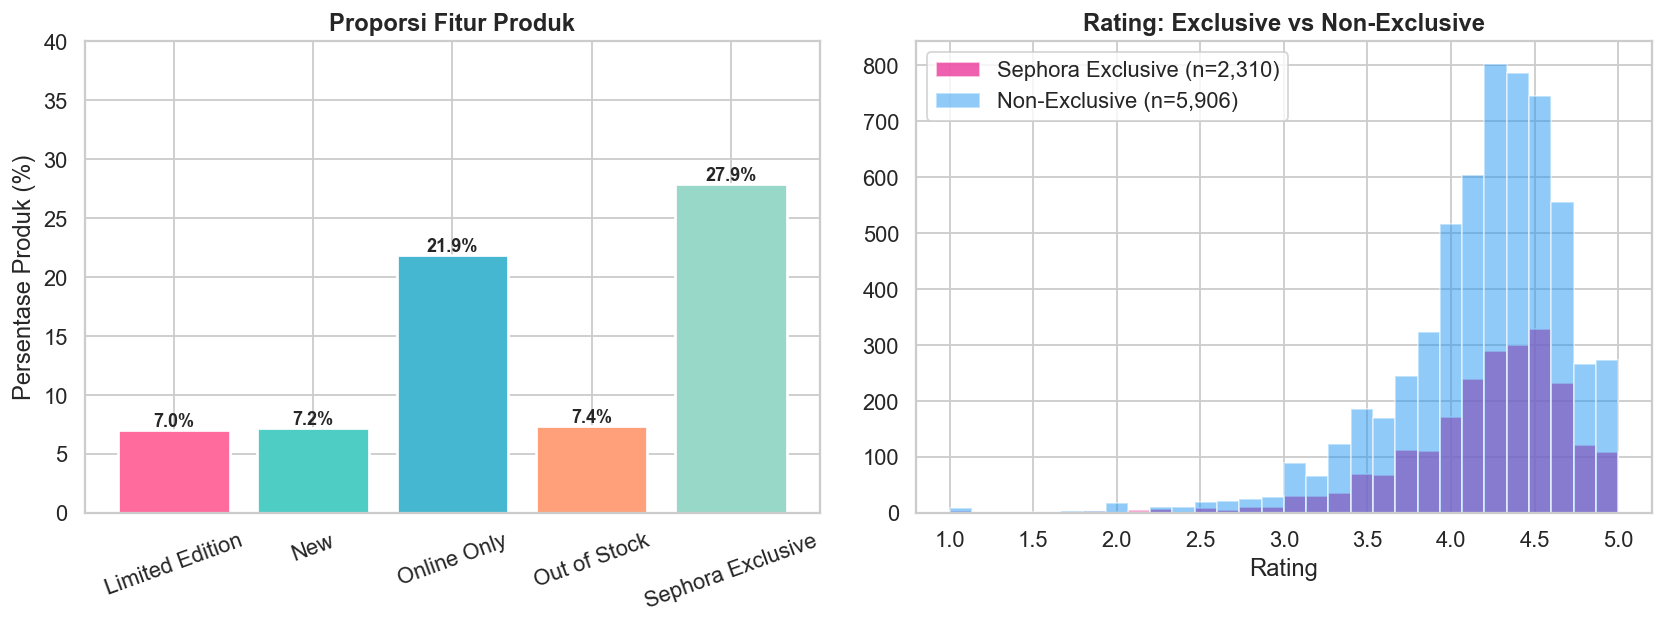


 Statistik Rating:
  Sephora Exclusive avg rating : 4.210
  Non-Exclusive avg rating     : 4.188


In [13]:
# Boolean features analysis
bool_cols = ['limited_edition','new','online_only','out_of_stock','sephora_exclusive']
bool_labels = ['Limited Edition','New','Online Only','Out of Stock','Sephora Exclusive']
values = [df[c].mean()*100 for c in bool_cols]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
# Bar chart
colors_b = ['#FF6B9D','#4ECDC4','#45B7D1','#FFA07A','#98D8C8']
bars = axes[0].bar(bool_labels, values, color=colors_b, edgecolor='white', linewidth=1.5)
axes[0].set_ylim(0, 40)
axes[0].set_ylabel('Persentase Produk (%)')
axes[0].set_title('Proporsi Fitur Produk', fontweight='bold')
axes[0].tick_params(axis='x', rotation=20)
for bar, v in zip(bars, values):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                 f'{v:.1f}%', ha='center', fontsize=10, fontweight='bold')

# Rating comparison: exclusive vs non-exclusive
excl = df[df['sephora_exclusive']==1]['rating'].dropna()
non_excl = df[df['sephora_exclusive']==0]['rating'].dropna()
axes[1].hist(excl, bins=30, alpha=0.7, color='#E91E8C', label=f'Sephora Exclusive (n={len(excl):,})')
axes[1].hist(non_excl, bins=30, alpha=0.5, color='#2196F3', label=f'Non-Exclusive (n={len(non_excl):,})')
axes[1].set_title('Rating: Exclusive vs Non-Exclusive', fontweight='bold')
axes[1].set_xlabel('Rating'); axes[1].legend()

plt.tight_layout()
plt.show()

print("\n Statistik Rating:")
print(f"  Sephora Exclusive avg rating : {excl.mean():.3f}")
print(f"  Non-Exclusive avg rating     : {non_excl.mean():.3f}")

## 8. Deep Dive: Kategori Skincare

Total produk Skincare: 2,420


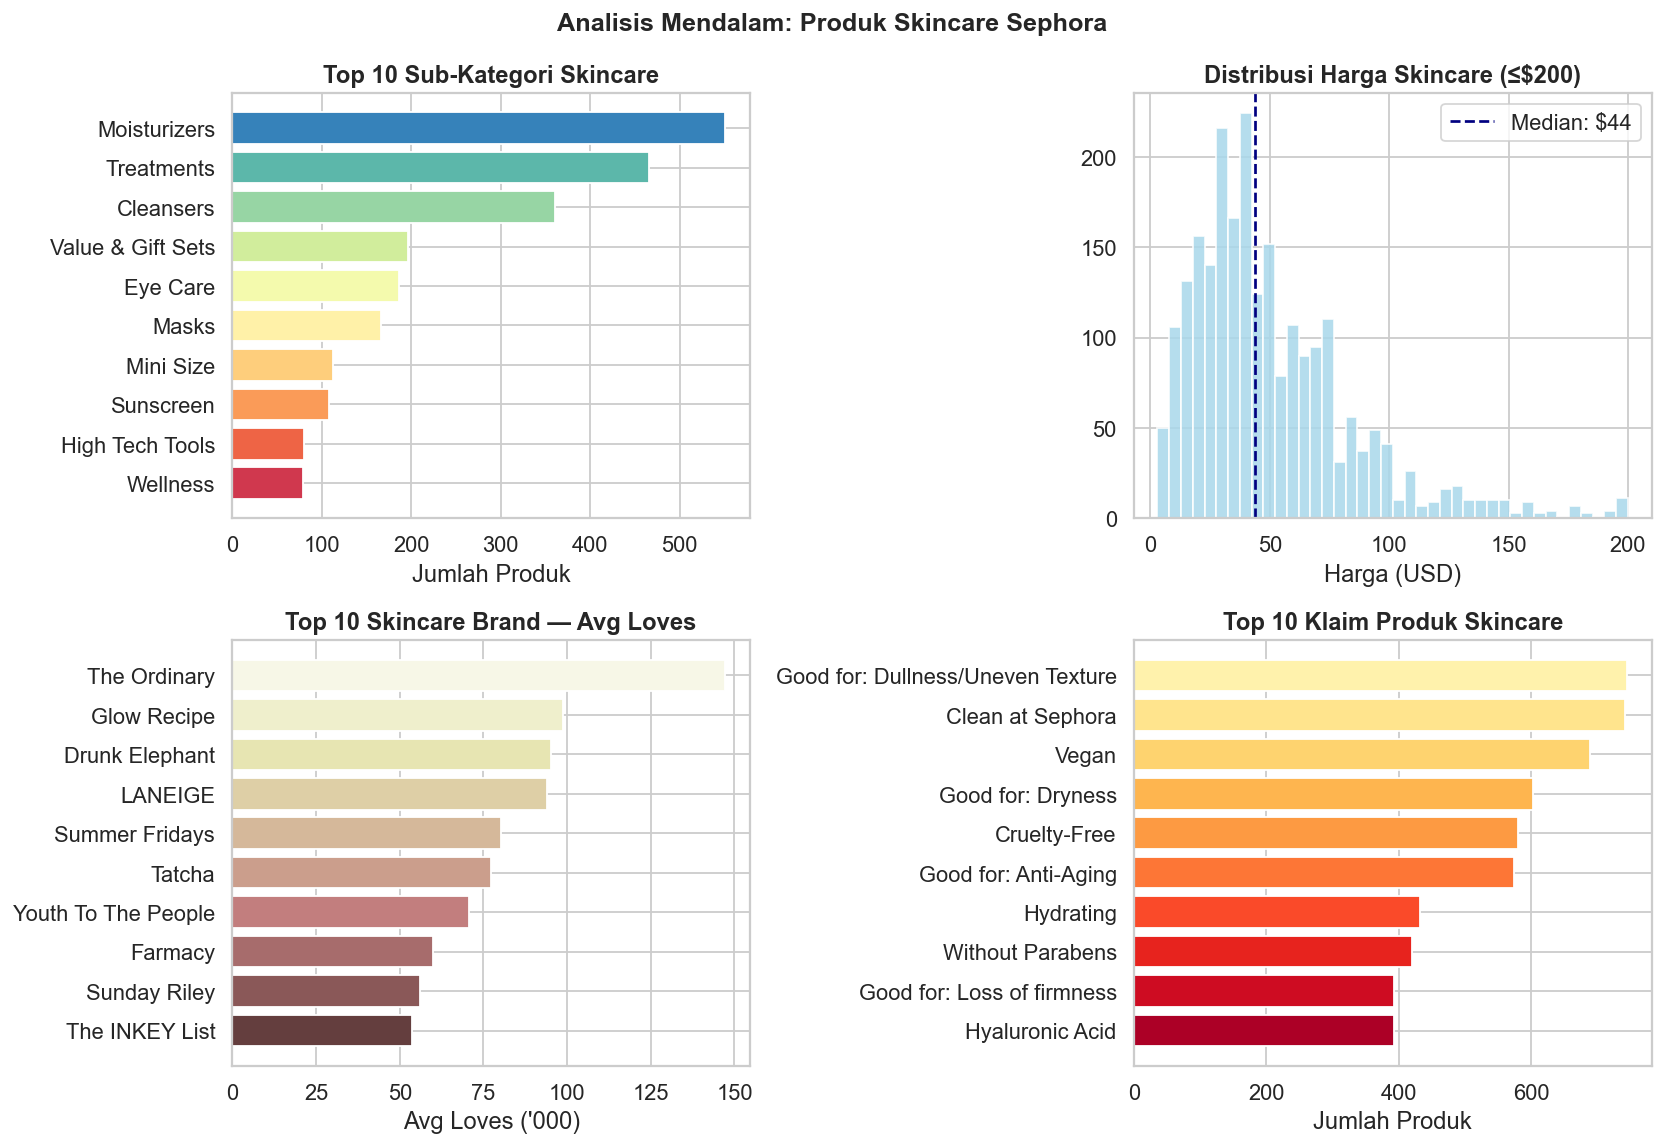

In [14]:
skincare = df[df['primary_category']=='Skincare'].copy()
print(f"Total produk Skincare: {len(skincare):,}")

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle('Analisis Mendalam: Produk Skincare Sephora', fontsize=14, fontweight='bold')

# Sub-category
sub_cat = skincare['secondary_category'].value_counts().head(10)
axes[0,0].barh(sub_cat.index[::-1], sub_cat.values[::-1],
               color=sns.color_palette('Spectral', 10))
axes[0,0].set_title('Top 10 Sub-Kategori Skincare', fontweight='bold')
axes[0,0].set_xlabel('Jumlah Produk')

# Price distribution skincare
axes[0,1].hist(skincare[skincare['price_usd']<=200]['price_usd'], bins=40,
               color='#A8D8EA', edgecolor='white', alpha=0.85)
axes[0,1].axvline(skincare['price_usd'].median(), color='navy', linestyle='--',
                   label=f"Median: ${skincare['price_usd'].median():.0f}")
axes[0,1].set_title('Distribusi Harga Skincare (≤$200)', fontweight='bold')
axes[0,1].set_xlabel('Harga (USD)'); axes[0,1].legend()

# Top skincare brands by avg loves
top_skin_brands = (skincare.groupby('brand_name')
                   .agg(avg_loves=('loves_count','mean'), count=('product_id','count'))
                   .query('count >= 5')
                   .nlargest(10, 'avg_loves'))
axes[1,0].barh(top_skin_brands.index[::-1], top_skin_brands['avg_loves'][::-1]/1000,
               color=sns.color_palette('pink', 10))
axes[1,0].set_title('Top 10 Skincare Brand — Avg Loves', fontweight='bold')
axes[1,0].set_xlabel("Avg Loves ('000)")

# Skincare highlights
skin_hl = [h for sub in skincare['highlights_list'] for h in sub]
top_skin_hl = Counter(skin_hl).most_common(10)
hl_names = [x[0] for x in top_skin_hl]
hl_vals  = [x[1] for x in top_skin_hl]
axes[1,1].barh(hl_names[::-1], hl_vals[::-1], color=sns.color_palette('YlOrRd_r', 10))
axes[1,1].set_title('Top 10 Klaim Produk Skincare', fontweight='bold')
axes[1,1].set_xlabel('Jumlah Produk')

plt.tight_layout()
plt.show()

## 9. Top Products Ranking

In [15]:
print("TOP 10 PRODUK — PALING BANYAK DICINTAI (Loves)")
top_loves = df.nlargest(10, 'loves_count')[['product_name','brand_name','loves_count','rating','price_usd','primary_category']]
top_loves['loves_count'] = top_loves['loves_count'].apply(lambda x: f'{x:,.0f}')
top_loves.reset_index(drop=True).style.background_gradient(subset=['rating'], cmap='YlGn')

TOP 10 PRODUK — PALING BANYAK DICINTAI (Loves)


,product_name,brand_name,loves_count,rating,price_usd,primary_category
0,Soft Pinch Liquid Blush,Rare Beauty by Selena Gomez,"1,401,068",4.535600,23.000000,Makeup
1,Radiant Creamy Concealer,NARS,"1,153,594",4.308000,32.000000,Makeup
2,Lip Sleeping Mask Intense Hydration with Vitamin C,LANEIGE,"1,081,315",4.350800,24.000000,Skincare
3,Cream Lip Stain Liquid Lipstick,SEPHORA COLLECTION,"1,029,051",4.320100,15.000000,Makeup
4,Gloss Bomb Universal Lip Luminizer,Fenty Beauty by Rihanna,"968,317",4.635700,21.000000,Makeup
5,Pro Filt’r Soft Matte Longwear Liquid Foundation,Fenty Beauty by Rihanna,"856,497",4.035600,40.000000,Makeup
6,Blush,NARS,"840,076",4.664300,32.000000,Makeup
7,Brow Wiz Ultra-Slim Precision Brow Pencil,Anastasia Beverly Hills,"834,189",4.405600,25.000000,Makeup
8,Translucent Loose Setting Powder,Laura Mercier,"813,497",4.502900,43.000000,Makeup
9,Niacinamide 10% + Zinc 1% Oil Control Serum,The Ordinary,"763,168",4.243900,6.000000,Skincare


In [16]:
print("TOP 10 PRODUK — RATING TERTINGGI (min 100 reviews)")
top_rated = (df[df['reviews'] >= 100]
             .nlargest(10, 'rating')
             [['product_name','brand_name','rating','reviews','loves_count','price_usd']])
top_rated.reset_index(drop=True).style.background_gradient(subset=['rating'], cmap='YlOrRd')

TOP 10 PRODUK — RATING TERTINGGI (min 100 reviews)


,product_name,brand_name,rating,reviews,loves_count,price_usd
0,Rapid Repair Hair Mask,BondiBoost,4.993700,158.000000,6772,29.950000
1,Heavenly Hydration Hair Mask,BondiBoost,4.981800,110.000000,1549,29.990000
2,Sparkling Cuvee Glass Jar Candle,VOLUSPA,4.964800,142.000000,1829,34.000000
3,Blonde Baby Hydrating Toning Purple Conditioner,BondiBoost,4.951800,228.000000,2632,29.950000
4,Frizz Fix Serum,BondiBoost,4.941200,119.000000,1244,23.990000
5,Hair Thickening Therapy Mask,BondiBoost,4.924900,253.000000,11214,29.950000
6,Elixir Hair Oil Treatment with Castor Oil,BondiBoost,4.921100,266.000000,9613,19.950000
7,Lucea 1 ½” Professional Straightening and Styling Iron,T3,4.917900,195.000000,4440,189.990000
8,Smooth ID 1” Digital Ceramic Flat Iron with Smart Heat Setting Personalization,T3,4.914300,105.000000,1191,249.000000
9,Heavenly Hydration Pre-Shampoo Hair Oil,BondiBoost,4.910900,101.000000,1884,29.990000


## 10. Korelasi Antar Variabel Numerik

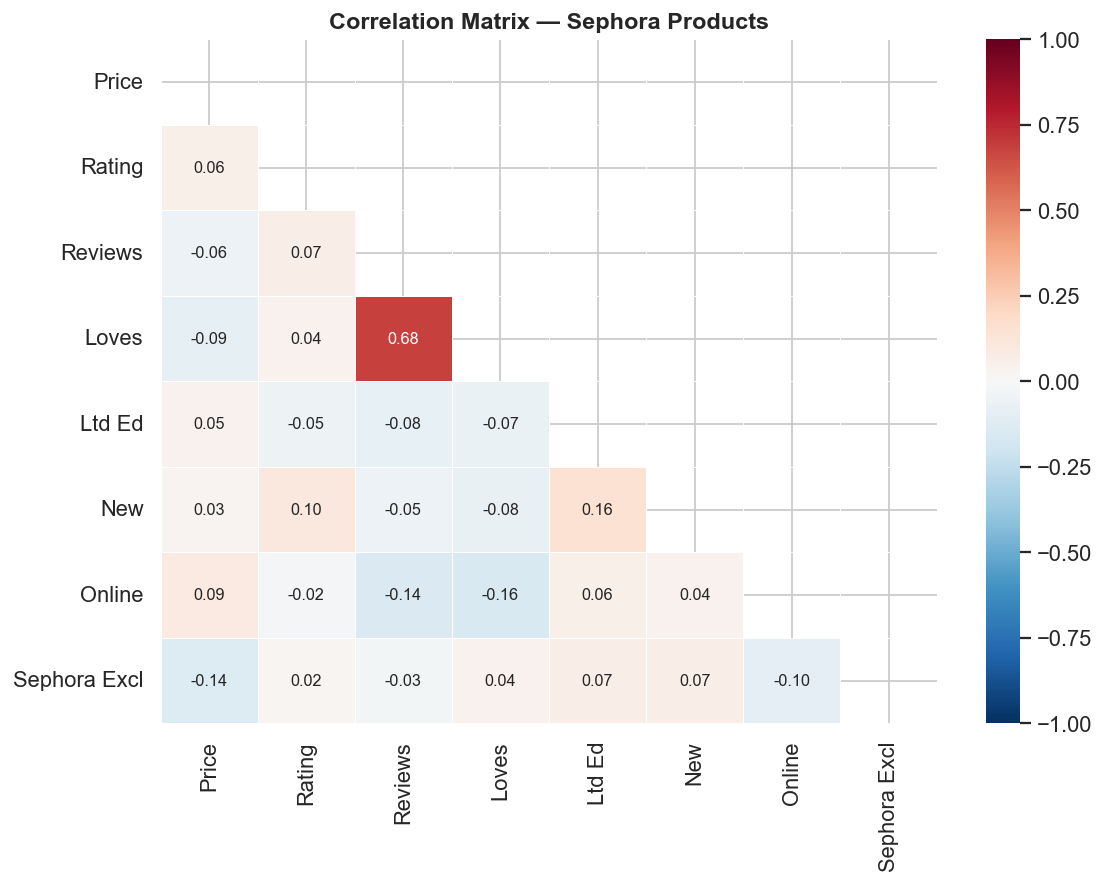

In [17]:
numeric_cols = ['price_usd','rating','reviews','loves_count',
                'limited_edition','new','online_only','sephora_exclusive']
corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, ax=ax,
            linewidths=0.5, annot_kws={'size': 9},
            xticklabels=['Price','Rating','Reviews','Loves','Ltd Ed','New','Online','Sephora Excl'],
            yticklabels=['Price','Rating','Reviews','Loves','Ltd Ed','New','Online','Sephora Excl'])
ax.set_title('Correlation Matrix — Sephora Products', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 11. Kesimpulan & Insights

### 🔑 Temuan Utama:

1. **Kategori Terbesar:** Skincare (28.5%) dan Makeup (27.9%) mendominasi katalog Sephora, diikuti Hair Care dan Fragrance.

2. **Harga:** Mayoritas produk (43.6%) berada di segmen Mid ($25–$50). Rata-rata harga $51.66 dengan median $35 — menunjukkan distribusi right-skewed karena produk luxury mahal.

3. **Rating:** Rata-rata rating sangat tinggi (4.19/5) dengan distribusi left-skewed — produk Sephora umumnya berkualitas tinggi atau terjadi selection bias (hanya produk baik yang tetap dijual).

4. **Brand Terpopuler:** SEPHORA COLLECTION memiliki produk terbanyak (352), namun brand premium seperti Charlotte Tilbury dan Fenty Beauty memiliki loves count rata-rata lebih tinggi.

5. **Highlights Terpopuler:** Vegan (31%), Cruelty-Free (21%), dan Clean at Sephora (18%) — menunjukkan tren konsumen yang semakin peduli lingkungan dan etika produksi.

6. **Sephora Exclusive:** Produk eksklusif Sephora memiliki rata-rata rating sedikit lebih tinggi dibanding non-eksklusif.

7. **Korelasi:** Reviews dan Loves berkorelasi kuat positif (>0.7) — produk yang banyak diulas juga banyak "dicintai". Price tidak berkorelasi signifikan dengan rating.

---
*Analisis ini merupakan bagian dari portofolio Data Science — Data Analyst*
